In [4]:
import numpy as np

# Define a haar function

def haar_filter(img):
    img=img.astype(np.float16)

    #Take every two neighboring columns and calculate their average.
    low_pass_cols=(img[:,0::2]+img[:,1::2])/2

    #Take every two neighboring columns and calculate their difference.
    high_pass_cols=np.abs((img[:,0::2]-img[:,1::2]))/2 #np.abs makes value positive

    #Wavelet Decomposition

    #Average of even and odd columns from Low pass columns
    LL=(low_pass_cols[:,0::2]+low_pass_cols[:,1::2])/2

    #Difference of even and odd columns from Low pass columns
    LH=np.abs((low_pass_cols[:,0::2]-low_pass_cols[:,1::2]))/2

    #Average of even and odd columns from High pass columns
    HL=(high_pass_cols[:,0::2]+high_pass_cols[:,1::2])/2

    #Difference of even and odd columns from High pass columns
    HH=np.abs((high_pass_cols[:,0::2]-high_pass_cols[:,1::2]))/2

    return LL,LH,HL,HH

    
    

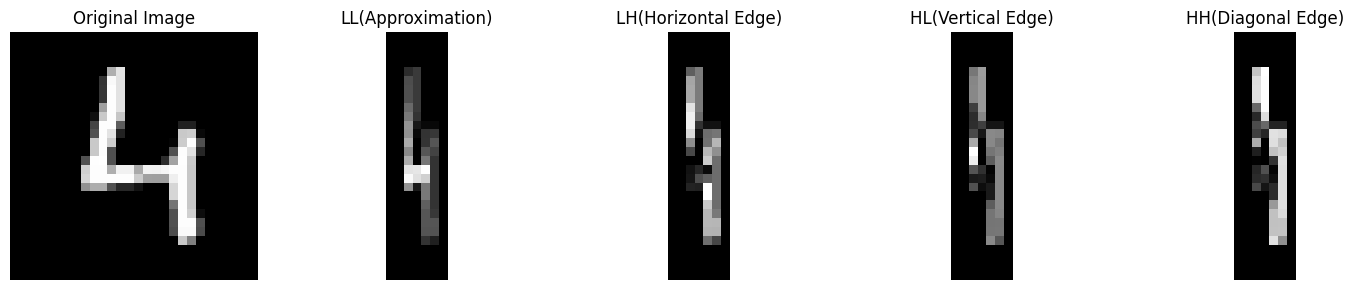

In [18]:
import cv2
img=cv2.imread('4.png',0) #0 means Grayscale
LL,LH,HL,HH=haar_filter(img)

images=[img,LL,LH,HL,HH]
image_title=['Original Image','LL(Approximation)','LH(Horizontal Edge)','HL(Vertical Edge)','HH(Diagonal Edge)']

import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i],cmap='gray',aspect='equal')
    plt.title(image_title[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

#The Haar wavelet decomposes the original image into one approximation component (LL) and three detail components (LH, HL and HH).
#LL retains the major shape and low-frequency information, while LH, HL and HH capture directional and diagonal high-frequency details.

In [17]:
for i in range(5):
    print(images[i].shape)

(28, 28)
(28, 7)
(28, 7)
(28, 7)
(28, 7)
